In [1]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.stats import norm
from scipy import interpolate
from scipy.optimize import minimize
from time import time
from scipy.optimize import curve_fit
import scipy.constants as cs
from datetime import datetime
from scipy.io import savemat, loadmat
import os
import shutil
import json
import glob
from tabulate import tabulate
from scipy.optimize import fsolve
import uncertainties.unumpy as unp
%matplotlib notebook

In [2]:
def fitRabi(t, A0, tau2, omega, phi, B0):
    return A0*np.exp(-t/tau2)*np.sin(omega*t + phi) + B0
def GammaThermalShotnoise(ktot, chi, nth): #From Rigetti paper, kappa with Amplitude decay
    #Superconducting qubit in a waveguide cavity with a coherence time approaching 0.1 ms
    #Using a qubit to measure photon-number statistics of a driven thermal oscillator
    return ktot/2 * np.real((np.sqrt((1+2*1j*chi/ktot)**2 + (8j * chi * nth / ktot))-1))
    #return ktot/2 * np.real((np.sqrt((1+2*1j*chi/ktot)**2 + (8j * chi * nth / ktot))-1))
    #return (1+2*1j*chi/ktot)**2 + (8j * chi * nth / ktot)
def GammaThermalShotnoiseSimple(ktot, chi, nth): #From Rigetti paper, kappa with Amplitude decay
    #Using a qubit to measure photon-number statistics of a driven thermal oscillator
    return ktot * chi**2/(ktot**2/4+chi**2)*nth
def GammaThermalShotnoise2(ktot, nth, N): #From Schoelkopf paper
    #N is the photon peak at frequency wq - N*chi
    #Photon shot noise dephasing in the strong-dispersive limit of circuit QED
    return ktot * ((nth + 1)*N + nth*(N + 1))
#Assume a (also decaying possible) cavity population and compare the increased decay to the T2 Echo
def T2Shotnoise(t, delta, ktot, chi, n, T2Echo, phi): #From Gambetta paper
    #Rapid Driven Reset of a Qubit Readout Resonator
    tau = (1-np.exp(-(ktot + 2j*chi)*t))/(ktot + 2j*chi)
    return 1/2*(1-np.imag(np.exp(-(1/T2Echo + 1j*delta)*t + (phi-2*n*chi*tau)*1j)))
#Cavity induced Ramsey oscillations
def T2Coh(t,chi,T2, n): # from Appendix E3 of Number-Resolved Photocounter for Propagating Microwave Mode R.
    return np.cos(n * np.sin(chi*t)) * np.exp( n * (np.cos(chi*t)-1)-t/T2)
def T2Thermal(t,chi,T2, nth): # from Appendix B1 of Dissipative Stabilization of Squeezing beyond 3 dB in a Microwave Mode
    #nth of the cavity
    return (nth*(1-np.cos(chi * t)) + 1) / (2*(1-np.cos(chi*t))*(nth+1)+1)*np.exp(-t/T2)
def BoseEinstein(f,T):
    return 1/(np.exp(cs.h*f/(cs.k*T))-1)
def Tphi(T1,T2):#this is valid if T1 and T2 have an exponential decay (T2 limited by 2T1 and e.g. white photon shot noise)
    #(1/f noise and several noise sources in general make a Gaussian noise statistics, so you have
    #T2 ~ exp(-t/2T1)*exp(-t**2/Tphi**2))
    return 1/(1/T2-1/(2*T1))
def TphiTrab(T1,Trab):
    return 1/(2/Trab-3/(2*T1))
def BoseEinsteinInverse(f,n):
    return cs.h*f/(cs.k*np.log(1/n+1))
def thermaldist(nmean, N):
    return nmean**N / (nmean+1)**(N+1)
def Poissondist(nmean,N):
    return np.exp(-nmean)*nmean**N / np.fact(N)
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def rotatedata(I,Q,angle):
    C = np.cos(angle)
    S = np.sin(angle)
    I_rotated = I * C - Q * S
    Q_rotated = I * S + Q * C
    return I_rotated,Q_rotated

def minimizeQ(angle,I,Q):
    I_rotated, Q_rotated = rotatedata(I,Q,angle)
    return abs(np.max(Q_rotated)-np.min(Q_rotated)) # Make Q as flat as possible
    #This function works for Rabi
    #All need same angle
    #Use function for Rabi, use rotation angle on all the others T1, T2, IQ blobs

In [3]:
Tfridgeoff = 7
Tfridge10Hz = 18
Tfridge50Hz = 34
Tfridge250Hz = 74
Tfridge500Hz = 104
Tfridge1000Hz = 143
Tsfridge = np.array([Tfridgeoff, Tfridge10Hz, Tfridge50Hz, Tfridge250Hz, Tfridge500Hz, Tfridge1000Hz])

### Extract qubit temp from the separate ef Rabi measurements with and wo pi pulse
Under the assmuption that P(f) -> 0 due to thermal excitation (justified for T<= 50 mK), so that $P(e) + P(g) = 1$ 

P(e) can be calculated by $P(e) = A_{sig}/(A_{ref}+A_{sig}) $

In [37]:
#1000Hz
file1 = r'\Rabi_efLengthSweep_JPA_Refl_LowP_detuned0.0MHz_long_readout_pulse_x180_2023_06_01-18-36-18.mat'
file2 = r'\Rabi_efLen_ther_JPAon_Refl_LowP_navg100000_250Hztrig_long_readout_pulse_x180_2023_06_01-19-21-57.mat'
#500Hz
file1 = r'\Rabi_efLengthSweep_JPA_Refl_LowP_detuned0.0MHz_long_readout_pulse_x180_2023_05_29-21-43-09.mat'
file2 = r'\Rabi_efLen_ther_JPAon_Refl_LowP_navg100000_250Hztrig_long_readout_pulse_x180_2023_05_29-22-44-25.mat'
# #250Hz
file1 = r'\Rabi_efLengthSweep_JPA_Refl_LowP_detuned0.0MHz_long_readout_pulse_x180_2023_05_20-17-00-59.mat'
file2 = r'\Rabi_efLen_ther_JPAon_Refl_LowP_navg1000000_250Hztrig_long_readout_pulse_x180_2023_05_20-21-30-12.mat'
#50Hz
file1 = r'\Rabi_efLengthSweep_JPA_Refl_LowP_detuned0.0MHz_long_readout_pulse_x180_2023_05_17-07-32-57.mat'
file2 = r'\Rabi_efLength_thermal_JPAon_Refl_LowP_navg1000000MHz_50Hztrig_long_readout_pulse_x180_2023_05_17-12-05-19.mat'
# #10Hz
file1 = r'\Rabi_efLengthSweep_JPA_Refl_LowP_detuned0.0MHz_long_readout_pulse_x180_2023_05_15-03-25-41.mat'
file2 = r'\Rabi_efLengthSweep_thermal_JPA_Refl_LowP_navg1000000MHz_long_readout_pulse_x180_2023_05_15-07-58-25.mat'
# #off
file1 = r'\\Rabi_efLengthSweep_JPA_Refl_LowP_detuned0.0MHz_long_readout_pulse_x180_2023_05_03-17-43-17.mat'
file2 = r'\Rabi_efLengthSweep_thermal_JPA_Refl_LowP_navg1000000MHz_long_readout_pulse_x180_2023_05_04-17-11-08.mat'

home_dir = '.\\Fig_4c'
folder = r'\QubitTemp\\'

data1 = loadmat(home_dir + folder + file1)
data2 = loadmat(home_dir + folder + file2)

Iexc = data1['I'][0]
Qexc = data1['Q'][0]
texc = data1['t_ns'][0]

Ith = data2['I'][0]
Qth = data2['Q'][0]
tth = data2['t_ns'][0]

tvec = tth/4

timestring1 = file1[-23:-4]
timestring2 = file2[-23:-4]
print('Time of Meas:' + timestring1)
print('Time of Meas:' + timestring2)

Time of Meas:2023_05_03-17-43-17
Time of Meas:2023_05_04-17-11-08


In [38]:
res = minimize(minimizeQ, x0 = [0.5],args = (Iexc,Qexc))
rotation_angle = res.x[0]
print('rotated by: ' + str(rotation_angle) + ' rad')
print('rotated by: ' + str(180/np.pi*rotation_angle) + ' deg')
Iexc_rot,Qexc_rot = rotatedata(Iexc,Qexc,rotation_angle)
print(abs(np.max(Qexc_rot)-np.min(Qexc_rot)))

rotated by: 0.7997194217596031 rad
rotated by: 45.820547661467906 deg
5.827054889198503e-06


In [39]:
res = minimize(minimizeQ, x0 = [0.2],args = (1000*Ith,1000*Qth))
rotation_angle_th = res.x[0]-0.02
print('rotated by: ' + str(rotation_angle_th) + ' rad')
print('rotated by: ' + str(180/np.pi*rotation_angle_th) + ' deg')
Ith_rot,Qth_rot = rotatedata(Ith,Qth,rotation_angle_th)
print(abs(np.max(Qth_rot)-np.min(Qth_rot)))

rotated by: 0.8409445540697034 rad
rotated by: 48.18257375270506 deg
1.704084283679085e-07


In [40]:
Aexc = np.sqrt(Iexc**2 + Qexc**2)
Ath = np.sqrt(Ith**2 + Qth**2)

<IPython.core.display.Javascript object>


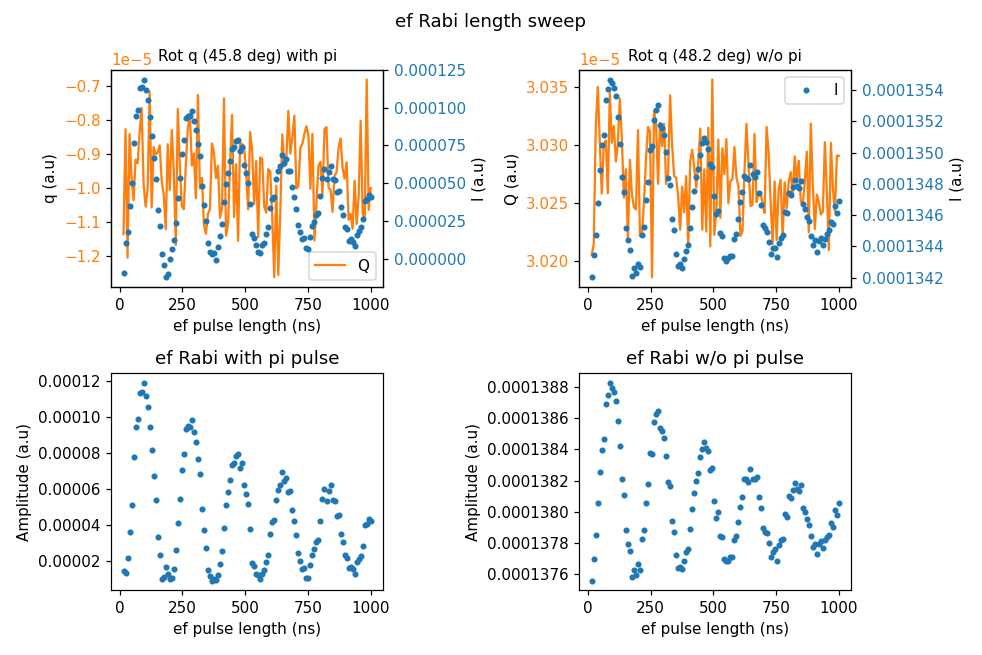

In [41]:
fig, ax = plt.subplots(2,2, figsize = (9,6))
plt.suptitle('ef Rabi length sweep')
#ax[0,0].plot(texc, Iexc_rot, '.',label ='I')
ax[0,0].plot(texc, Qexc_rot, '-', color = 'C1', label  = 'Q')
ax[0,0].set_xlabel('ef pulse length (ns)')
ax[0,0].set_ylabel('q (a.u)')
ax[0,0].tick_params(axis='y', labelcolor='C1')
ax1 = ax[0,0].twinx()
ax1.plot(tth, Iexc_rot,'.', color = 'C0', label  = 'I')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.set_ylabel('I (a.u)')
ax[0,0].legend()
ax[0,0].set_title('Rot q (' + str(np.round(180/np.pi*rotation_angle,1)) + ' deg) with pi', size = 10)
ax[0,1].plot(tth, Qth_rot, '-', color = 'C1', label = 'Q')
ax[0,1].set_title('Rot q (' + str(np.round(180/np.pi*rotation_angle_th,1)) + ' deg) w/o pi', size = 10)
ax[0,1].set_xlabel('ef pulse length (ns)')
ax[0,1].set_ylabel('Q (a.u)')
ax[0,1].tick_params(axis='y', labelcolor='C1')
ax2 = ax[0,1].twinx()
ax2.plot(tth, Ith_rot,'.', color = 'C0', label  = 'I')
ax2.tick_params(axis='y', labelcolor='C0')
ax2.set_ylabel('I (a.u)')
ax[1,0].plot(texc, Aexc, '.')
ax[1,0].set_title('ef Rabi with pi pulse')
ax[1,0].set_xlabel('ef pulse length (ns)')
ax[1,0].set_ylabel('Amplitude (a.u)')
plt.legend()
ax[1,1].plot(tth, Ath, '.')
ax[1,1].set_title('ef Rabi w/o pi pulse')
ax[1,1].set_xlabel('ef pulse length (ns)')
ax[1,1].set_ylabel('Amplitude (a.u)')
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


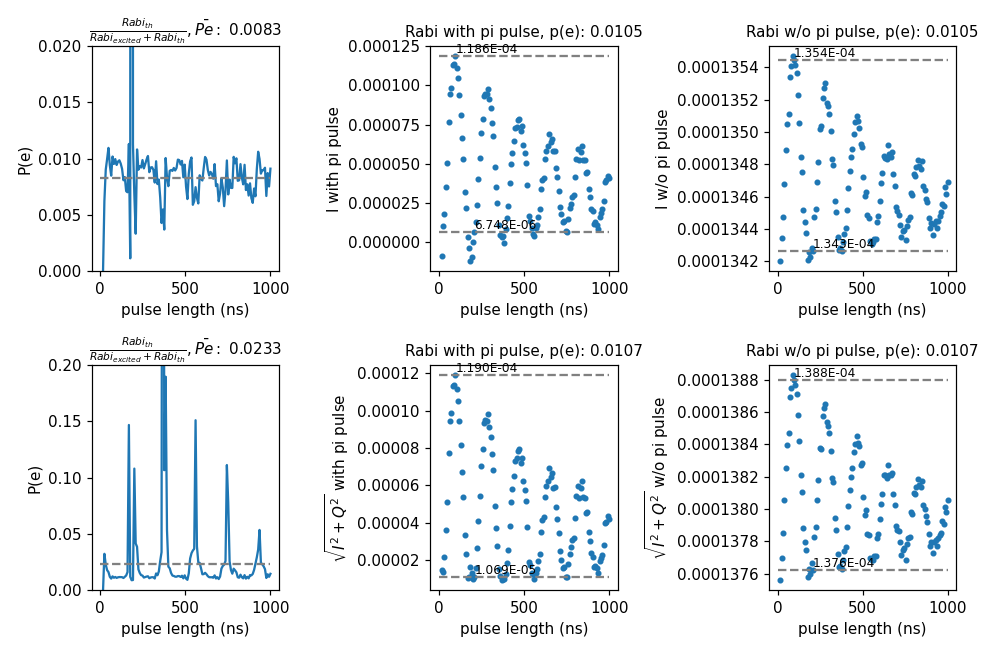

1.1821060363363851e-06 0.00011182110922336101
Excited state probability I: 0.010460817717617485
Excited state probability $ \sqrt{I^2 + Q^2} $: 0.01069732793100299


In [42]:
Pe_time = (Ith_rot-np.min(Ith_rot))/(Ith_rot-np.min(Ith_rot) + Iexc_rot-np.min(Iexc_rot))
Pe_mean = np.mean(Pe_time[abs(Pe_time-np.mean(Pe_time))<0.25])

fig, ax = plt.subplots(2,3, figsize = (9,6))
ax[0,0].plot(tth, Pe_time)
ax[0,0].set_ylim([0,0.02])
ax[0,0].hlines(Pe_mean, 0, np.max(tth), colors='gray', linestyles='dashed')
ax[0,0].set_title(r'$ \frac{Rabi_{th} }{Rabi_{excited} + Rabi_{th}},  \bar{Pe}:$ ' + str(np.round(Pe_mean,4)), fontsize = 10)
ax[0,0].set_xlabel('pulse length (ns)')
ax[0,0].set_ylabel('P(e)')

tpi = 100
t2pi = 208
tpi_th = 100
t2pi_th = 208
idxpi = np.argmin(abs(texc-tpi))
idx2pi = np.argmin(abs(texc-t2pi))
idxpi_th = np.argmin(abs(tth-tpi_th))
idx2pi_th = np.argmin(abs(tth-t2pi_th))

Iref = Iexc_rot[idxpi]-Iexc_rot[idx2pi]
Isig = Ith_rot[idxpi_th] - Ith_rot[idx2pi_th]
Aref = Aexc[idxpi]-Aexc[idx2pi]
Asig = Ath[idxpi_th] - Ath[idx2pi_th]
print(Isig,Iref)
Pe = Isig/(Isig + Iref)
PeAmp = Asig/(Asig + Aref)
print('Excited state probability I: ' + str(Pe))
print('Excited state probability $ \sqrt{I^2 + Q^2} $: ' + str(PeAmp))

ax[0,1].plot(texc, Iexc_rot, '.',label ='I')
ax[0,1].hlines(Iexc_rot[idxpi],0, np.max(tth), colors='gray', linestyles='dashed' )
ax[0,1].hlines(Iexc_rot[idx2pi],0, np.max(tth), colors='gray', linestyles='dashed' )
ax[0,1].text(texc[idxpi], Iexc_rot[idxpi], '{:.3E}'.format(Iexc_rot[idxpi]),verticalalignment ='bottom',horizontalalignment ='left',color ='black', fontsize = 8)
ax[0,1].text(texc[idx2pi], Iexc_rot[idx2pi], '{:.3E}'.format(Iexc_rot[idx2pi]),verticalalignment ='bottom',horizontalalignment ='left',color ='black', fontsize = 8)
ax[0,1].set_xlabel('pulse length (ns)')
ax[0,1].set_ylabel('I with pi pulse')
ax[0,1].set_title('Rabi with pi pulse, p(e): ' + str(np.round(Pe,4)), fontsize = 10)


ax[0,2].plot(tth, Ith_rot, '.',label ='I')
ax[0,2].hlines(Ith_rot[idxpi_th],0, np.max(tth), colors='gray', linestyles='dashed' )
ax[0,2].hlines(Ith_rot[idx2pi_th],0, np.max(tth), colors='gray', linestyles='dashed' )
ax[0,2].text(tth[idxpi_th], Ith_rot[idxpi_th], '{:.3E}'.format(Ith_rot[idxpi_th]),verticalalignment ='bottom',horizontalalignment ='left',color ='black', fontsize = 8)
ax[0,2].text(tth[idx2pi_th], Ith_rot[idx2pi_th], '{:.3E}'.format(Ith_rot[idx2pi_th]),verticalalignment ='bottom',horizontalalignment ='left',color ='black', fontsize = 8)
ax[0,2].set_xlabel('pulse length (ns)')
ax[0,2].set_ylabel('I w/o pi pulse')
ax[0,2].set_title('Rabi w/o pi pulse, p(e): ' + str(np.round(Pe,4)), fontsize = 10)

Pe_timeAmp = (Ath-np.min(Ath))/(Ath-np.min(Ath) + Aexc-np.min(Aexc))
Pe_meanAmp = np.mean(Pe_timeAmp[abs(Pe_timeAmp-np.mean(Pe_timeAmp))<0.25])

ax[1,0].plot(tth, Pe_timeAmp)
ax[1,0].set_ylim([0.0,0.2])
ax[1,0].hlines(Pe_meanAmp, 0, np.max(tth), colors='gray', linestyles='dashed')
ax[1,0].set_title(r'$ \frac{Rabi_{th} }{Rabi_{excited} + Rabi_{th}},  \bar{Pe}:$ ' + str(np.round(Pe_meanAmp,4)), fontsize = 10)
ax[1,0].set_xlabel('pulse length (ns)')
ax[1,0].set_ylabel('P(e)')

ax[1,1].plot(texc, Aexc, '.',label ='I')
ax[1,1].hlines(Aexc[idxpi],0, np.max(tth), colors='gray', linestyles='dashed' )
ax[1,1].hlines(Aexc[idx2pi],0, np.max(tth), colors='gray', linestyles='dashed' )
ax[1,1].text(texc[idxpi], Aexc[idxpi], '{:.3E}'.format(Aexc[idxpi]),verticalalignment ='bottom',horizontalalignment ='left',color ='black', fontsize = 8)
ax[1,1].text(texc[idx2pi], Aexc[idx2pi], '{:.3E}'.format(Aexc[idx2pi]),verticalalignment ='bottom',horizontalalignment ='left',color ='black', fontsize = 8)
ax[1,1].set_xlabel('pulse length (ns)')
ax[1,1].set_ylabel(r'$ \sqrt{I^2+Q^2}$ with pi pulse')
ax[1,1].set_title('Rabi with pi pulse, p(e): ' + str(np.round(PeAmp,4)), fontsize = 10)


ax[1,2].plot(tth, Ath, '.',label ='I')
ax[1,2].hlines(Ath[idxpi_th],0, np.max(tth), colors='gray', linestyles='dashed' )
ax[1,2].hlines(Ath[idx2pi_th],0, np.max(tth), colors='gray', linestyles='dashed' )
ax[1,2].text(tth[idxpi_th], Ath[idxpi_th], '{:.3E}'.format(Ath[idxpi_th]),verticalalignment ='bottom',horizontalalignment ='left',color ='black', fontsize = 8)
ax[1,2].text(tth[idx2pi_th], Ath[idx2pi_th], '{:.3E}'.format(Ath[idx2pi_th]),verticalalignment ='bottom',horizontalalignment ='left',color ='black', fontsize = 8)
ax[1,2].set_xlabel('pulse length (ns)')
ax[1,2].set_ylabel(r'$ \sqrt{I^2+Q^2}$ w/o pi pulse')
ax[1,2].set_title('Rabi w/o pi pulse, p(e): ' + str(np.round(PeAmp,4)), fontsize = 10)
plt.tight_layout()


# plt.savefig(home_dir + folder + '\\' + 'Qubit_temp_Pe_SeparateRabi_files_' + trig + '_' + timestring1 + '_' + timestring2 + '.png')

In [44]:
from scipy import constants as cs
def MaxBoltz2States(f1, f2, T):
    Z = np.exp(-(cs.h*f1) / (cs.k*T)) + np.exp(-(cs.h*f2) / (cs.k*T))
    return np.exp(-(cs.h*f1) / (cs.k*T))/Z, np.exp(-(cs.h*f2) / (cs.k*T))/Z

def MaxBoltz2States_unp(f1, f2, T):
    Z = unp.exp(-(cs.h*f1) / (cs.k*T)) + unp.exp(-(cs.h*f2) / (cs.k*T))
    return unp.exp(-(cs.h*f1) / (cs.k*T))/Z, unp.exp(-(cs.h*f2) / (cs.k*T))/Z

def MaxBoltz3States(f1, f2, T):
    Z = 1 + np.exp(-(cs.h*f1) / (cs.k*T)) + np.exp(-(cs.h*f2) / (cs.k*T))
    return 1 / Z, np.exp(-(cs.h*f1) / (cs.k*T)) / Z, np.exp(-(cs.h*f2) / (cs.k*T)) / Z

def MaxBoltz3States_unp(f1, f2, T):
    Z = 1 + unp.exp(-(cs.h*f1) / (cs.k*T)) + unp.exp(-(cs.h*f2) / (cs.k*T))
    return 1 / Z, unp.exp(-(cs.h*f1) / (cs.k*T)) / Z, unp.exp(-(cs.h*f2) / (cs.k*T)) / Z

In [45]:
qubit_LO = 6.3e9
qubit_IF = -48.5e6
qubit_ef_IF = -265.6e6
freqge = qubit_IF + qubit_LO
freqef = qubit_ef_IF + qubit_LO

In [46]:
def getQubitTemp2States(T,f1,f2,pe):
    p = MaxBoltz2States(f1,f2,T)
#     print('current e occupation: ' +str(p[1]))
    #print(abs(p[1]-pe))
    return abs(p[1]-pe) # Make Q as flat as possible
def getQubitTemp3States(T,f1,f2,pe):
    p = MaxBoltz3States(f1,f2,T)
#     print('current e occupation: ' +str(p[1]))
    #print(abs(p[1]-pe))
    return abs(p[1]-pe) # Make Q as flat as possible

<IPython.core.display.Javascript object>


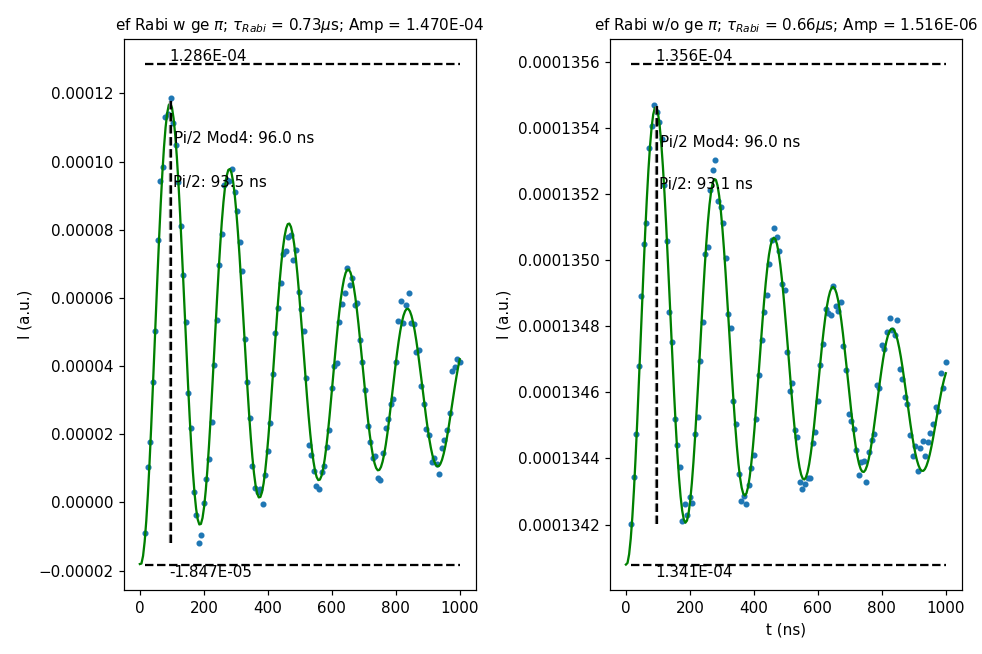

##########################Qubit temperature####################################
Lower bound
Expected fridge Temp: 0.0651799318+/-0.0000000027
Occupation two states: (0.9900779322179217+/-1.8626450996327515e-09, 0.009922067782078164+/-1.8626450996327515e-09)

Mean
Expected fridge Temp: 0.0655883912+/-0.0000000026
Occupation two states: (0.9897923370562217+/-1.8626451429862575e-09, 0.01020766294377831+/-1.8626451429862573e-09)

Upper bound
Expected fridge Temp: 0.0659906350+/-0.0000000032
Occupation two states: (0.9895067418945215+/-2.281265040251275e-09, 0.010493258105478465+/-2.281265040251275e-09)
#################################################################
0.0656+/-0.0004


In [50]:
from uncertainties import ufloat

def fitfunction1(t, A0, tau2, omega, phi, B0):
    return A0*np.exp(-t/tau2)*np.sin(omega*t+phi)+B0

def fitfunction1_unp(t, A0, tau2, omega, phi, B0):
    return A0*unp.exp(-t/tau2)*unp.sin(omega*t+phi)+B0

def fitfunction2(t, A0, tau2, omega, phi, B0, asy):
    return A0*np.exp(-t/tau2)*np.sin(omega*t+phi)+B0+asy*t

fitfunction = fitfunction2

xdatafit = 4*tvec
xplot = np.linspace(0,4*np.max(tvec),200)
ydatafit = Iexc_rot
pguess = [(np.max(ydatafit)-np.mean(ydatafit))*1.2, 800, 2*np.pi/(4*np.max(tvec)/4.96),np.pi/2*np.sign(ydatafit[0]-np.mean(ydatafit)),np.min(ydatafit)+(np.max(ydatafit)-np.min(ydatafit))/2]
boundslow = [0,100,0,-4,np.min(ydatafit)]
boundshigh = [2*np.max(ydatafit),3000000,0.2,4,np.max(ydatafit)]
if fitfunction == fitfunction2:
    pguess.append(8e-9)
    boundslow.append(-1)
    boundshigh.append(1)
# print('boundslow: ' + str(boundslow))
# print('boundshigh: ' + str(boundshigh))

ydatafit2 = Ith_rot
pguess2 = [(np.max(ydatafit2)-np.mean(ydatafit2))*1.12, 750, 2*np.pi/(4*np.max(tvec)/4.92),np.pi/2*np.sign(ydatafit2[0]-np.mean(ydatafit2)),np.min(ydatafit2)+(np.max(ydatafit2)-np.min(ydatafit2))/2.0]
boundslow2 = [0,100,0,-4,np.min(ydatafit2)]
boundshigh2 = [2*np.max(ydatafit2),3000000,0.2,4,np.max(ydatafit2)]
if fitfunction == fitfunction2:
    pguess2.append(0)
    boundslow2.append(-1)
    boundshigh2.append(1)
# print('boundslow: ' + str(boundslow2))
# print('boundshigh: ' + str(boundshigh2))

fig, ax = plt.subplots(1,2, figsize = (9,6))
ax[0].plot(4*tvec, ydatafit,".")
ax[1].plot(4*tvec, ydatafit2,".")
# print('pguess ' + str(pguess))
# print('pguess2 ' + str(pguess2))


try:
    full_output = curve_fit(fitfunction, 4*tvec, ydatafit, p0 = pguess, full_output=True)
    popt = full_output[0]
    pcov = full_output[1]
    infodict = full_output[2:]
    ax[0].plot(xplot, fitfunction(xplot, *popt), 'g-')
#     print('Fit 1 successful with popt: ' + str(popt))

except:
    ax[0].plot(xplot, fitfunction(xplot, *pguess), 'g-')
    popt = pguess
#     print('Fit unsuccessful with pguess: ' + str(pguess))
ind_omegahalf = np.argmin(abs(4*tvec-(2*np.pi)/popt[2]/2.0))
xfine = np.linspace(0,(2*np.pi)/popt[2]/1.5)
if ydatafit[0]>ydatafit[ind_omegahalf]:
    pipulselen = xfine[np.argmin(fitfunction(xfine, *popt))]
    pipulselenMod4 = 4*tvec[np.argmin(fitfunction(4*tvec[0:int(ind_omegahalf*1.5)], *popt))]
else:
    pipulselen = xfine[np.argmax(fitfunction(xfine, *popt))]
    pipulselenMod4 = 4*tvec[np.argmax(fitfunction(4*tvec[0:int(ind_omegahalf*1.5)], *popt))]

ax[0].vlines(pipulselen, np.min(ydatafit),np.max(ydatafit), color = 'gray', linestyle = 'dashed')
ax[0].vlines(pipulselenMod4, np.min(ydatafit),np.max(ydatafit), color = 'black', linestyle = 'dashed')
ax[0].text(pipulselen+10,np.min(ydatafit) + (np.max(ydatafit)-np.min(ydatafit))*0.8, 'Pi/2: ' + str(np.round(pipulselen,1)) + ' ns', color = 'black', size = '10')
ax[0].text(pipulselenMod4+10,np.min(ydatafit) + (np.max(ydatafit)-np.min(ydatafit))*0.9, 'Pi/2 Mod4: ' + str(np.round(pipulselenMod4,1)) + ' ns', color = 'black', size = '10')
ax[0].hlines(popt[4]-popt[0], np.min(xdatafit),np.max(xdatafit), color = 'black', linestyle = 'dashed')
ax[0].hlines(popt[4]+popt[0], np.min(xdatafit),np.max(xdatafit), color = 'black', linestyle = 'dashed')
ax[0].text(pipulselen,popt[4]-popt[0], '{:.3E}'.format(popt[4]-popt[0]), color = 'black', verticalalignment = 'top', size = '10')
ax[0].text(pipulselen,popt[4]+popt[0], '{:.3E}'.format(popt[4]+popt[0]), color = 'black', verticalalignment = 'bottom', size = '10')

    
try:
    full_output = curve_fit(fitfunction, 4*tvec, ydatafit2,p0 = pguess2, bounds=(boundslow2,boundshigh2), full_output=True)
    popt2 = full_output[0]
    pcov2 = full_output[1]
    infodict2 = full_output[2:]
#     print('Fit 2 successful with popt: ' + str(popt2))
    ax[1].plot(xplot, fitfunction(xplot, *popt2), 'g-')
    
    ind_omegahalf = np.argmin(abs(4*tvec-(2*np.pi)/popt2[2]/2.0))
    xfine = np.linspace(0,(2*np.pi)/popt2[2]/1.5)
    if ydatafit2[0]>ydatafit2[ind_omegahalf]:
        pipulselen2 = xfine[np.argmin(fitfunction(xfine, *popt2))]
        pipulselenMod42 = 4*tvec[np.argmin(fitfunction(4*tvec[0:int(ind_omegahalf*1.5)], *popt2))]
    else:
        pipulselen2 = xfine[np.argmax(fitfunction(xfine, *popt2))]
        pipulselenMod42 = 4*tvec[np.argmax(fitfunction(4*tvec[0:int(ind_omegahalf*1.5)], *popt2))]


    ax[1].vlines(pipulselen2, np.min(ydatafit2),np.max(ydatafit2), color = 'gray', linestyle = 'dashed')
    ax[1].vlines(pipulselenMod42, np.min(ydatafit2),np.max(ydatafit2), color = 'black', linestyle = 'dashed')
    ax[1].text(pipulselen2+10,np.min(ydatafit2) + (np.max(ydatafit2)-np.min(ydatafit2))*0.8, 'Pi/2: ' + str(np.round(pipulselen2,1)) + ' ns', color = 'black', size = '10')
    ax[1].text(pipulselenMod42+10,np.min(ydatafit2) + (np.max(ydatafit2)-np.min(ydatafit2))*0.9, 'Pi/2 Mod4: ' + str(np.round(pipulselenMod42,1)) + ' ns', color = 'black', size = '10')
    ax[1].hlines(popt2[4]-popt2[0], np.min(xdatafit),np.max(xdatafit), color = 'black', linestyle = 'dashed')
    ax[1].hlines(popt2[4]+popt2[0], np.min(xdatafit),np.max(xdatafit), color = 'black', linestyle = 'dashed')
    ax[1].text(pipulselen2,popt2[4]-popt2[0], '{:.3E}'.format(popt2[4]-popt2[0]), color = 'black', verticalalignment = 'top', size = '10')
    ax[1].text(pipulselen2,popt2[4]+popt2[0], '{:.3E}'.format(popt2[4]+popt2[0]), color = 'black', verticalalignment = 'bottom', size = '10')

except:
    ax[1].plot(xplot, fitfunction(xplot, *pguess2), 'g-')
    popt2 = pguess2
#     print('Fit 2 unsuccessful with pguess: ' + str(pguess2))
#     print('Min bounds: ' + str(boundslow2))
#     print('Max bounds: ' + str(boundshigh2))


Pe1 = ufloat(popt[0], np.sqrt(np.diag(pcov))[0])
Pe2 = ufloat(popt2[0], np.sqrt(np.diag(pcov2))[0])
Pe = popt2[0]/(popt2[0]+popt[0])
Pe_unp = Pe2/(Pe2+Pe1)



from scipy.optimize import leastsq

confidence_interval = 1

res_leastsq = leastsq(getQubitTemp2States, x0 = 0.12, args = (0, freqge, Pe), full_output = True)
leastsq_stdev = np.sqrt(res_leastsq[1]*res_leastsq[2]['fvec'])[0][0]

res_leastsq_upper = leastsq(getQubitTemp2States, x0 = 0.12, args = (0, freqge, Pe_unp.n+confidence_interval*Pe_unp.std_dev), full_output = True)
leastsq_stdev_upper = np.sqrt(res_leastsq_upper[1]*res_leastsq_upper[2]['fvec'])[0][0]

res_leastsq_lower = leastsq(getQubitTemp2States, x0 = 0.12, args = (0, freqge, Pe_unp.n-confidence_interval*Pe_unp.std_dev), full_output = True)
leastsq_stdev_lower = np.sqrt(res_leastsq_lower[1]*res_leastsq_lower[2]['fvec'])[0][0]
#########################################################################################



print('##########################Qubit temperature####################################')
T1_unp_lower = ufloat(res_leastsq_lower[0][0],leastsq_stdev_lower)
print('Lower bound')
print('Expected fridge Temp: ' + str(T1_unp_lower))
print('Occupation two states: ' + str(MaxBoltz2States_unp(0, freqge, T1_unp_lower)))

T1_unp = ufloat(res_leastsq[0][0],leastsq_stdev)
print('\nMean')
print('Expected fridge Temp: ' + str(T1_unp))
print('Occupation two states: ' + str(MaxBoltz2States_unp(0, freqge, T1_unp)))

T1_unp_upper = ufloat(res_leastsq_upper[0][0],leastsq_stdev_upper)
print('\nUpper bound')
print('Expected fridge Temp: ' + str(T1_unp_upper))
print('Occupation two states: ' + str(MaxBoltz2States_unp(0, freqge, T1_unp_upper)))
print('#################################################################')

print(ufloat(T1_unp.nominal_value,np.std([T1_unp_lower.nominal_value,T1_unp.nominal_value,T1_unp_upper.nominal_value],ddof=1)))

ax[0].set_ylabel('I (a.u.)')
ax[0].set_title(r'ef Rabi w ge $\pi$; $ \tau_{Rabi} $ = ' + str(np.round(popt[1]*1e-3,2)) + r'$ \mu$s; Amp = {:.3E}'.format(2*popt[0]),size = 10)

ax[1].set_xlabel('t (ns)')
ax[1].set_ylabel('I (a.u.)')
ax[1].set_title(r'ef Rabi w/o ge $\pi$; $ \tau_{Rabi} $ = ' + str(np.round(popt2[1]*1e-3,2)) + r'$ \mu$s; Amp = {:.3E}'.format(2*popt2[0]),size = 10)

plt.tight_layout()
plt.show()

#cold
0.0656+/-0.0004

#10Hz
0.06687+/-0.00026

#50Hz
0.07953+/-0.00033

#250Hz
0.1111+/-0.0007

#500Hz
0.1270+/-0.0011

#1000Hz
0.1613+/-0.0025